In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import *
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.calibration import CalibrationDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold




In [7]:
X_train = pd.read_csv("X_train.csv", index_col=0)
X_test  = pd.read_csv("X_test.csv", index_col=0)
y_train = pd.read_csv("y_train.csv", index_col=0).iloc[:,0]
y_test  = pd.read_csv("y_test.csv", index_col=0).iloc[:,0]

X_train.shape, X_test.shape, y_train.value_counts(), y_test.value_counts()

((609, 32),
 (153, 32),
 DESERTA
 0    527
 1     82
 Name: count, dtype: int64,
 DESERTA
 0    133
 1     20
 Name: count, dtype: int64)

In [8]:
# Fuerza categóricas a string para OHE robusto
X_train = X_train.apply(lambda s: s.astype(str))
X_test  = X_test.apply(lambda s: s.astype(str))

cat_cols = X_train.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop"
)

In [9]:
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced_subsample",  # maneja desbalance
    max_depth=None,
    min_samples_leaf=2,                 # suaviza un poco, reduce overfitting
    n_jobs=-1,
    random_state=42
)

rf_pipe = Pipeline([("prep", preprocessor), ("clf", rf)])
rf_pipe.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
proba_rf = rf_pipe.predict_proba(X_test)[:,1]
pred_rf  = (proba_rf >= 0.5).astype(int)

In [13]:
cm = confusion_matrix(y_test, pred_rf, labels=[0,1])
cm_df = pd.DataFrame(cm, index=["Real 0", "Real 1"], columns=["Pred 0", "Pred 1"])
print("\nMatriz de confusión (frecuencia absoluta):")
display(cm_df)


Matriz de confusión (frecuencia absoluta):


,Pred 0,Pred 1
Real 0,130,3
Real 1,10,10


In [14]:
cm_pct = (cm / cm.sum()) * 100.0          # % sobre el total de observaciones
cm_pct_df = pd.DataFrame(np.round(cm_pct, 2),
                         index=["Real 0", "Real 1"],
                         columns=["Pred 0", "Pred 1"])
print("\nMatriz de confusión (frecuencia relativa % del total):")
display(cm_pct_df)


Matriz de confusión (frecuencia relativa % del total):


,Pred 0,Pred 1
Real 0,84.97,1.96
Real 1,6.54,6.54


In [16]:
print(classification_report(y_test, pred_rf, digits=3, target_names=["No deserta (0)", "Deserta (1)"]))

                precision    recall  f1-score   support

No deserta (0)      0.929     0.977     0.952       133
   Deserta (1)      0.769     0.500     0.606        20

      accuracy                          0.915       153
     macro avg      0.849     0.739     0.779       153
  weighted avg      0.908     0.915     0.907       153



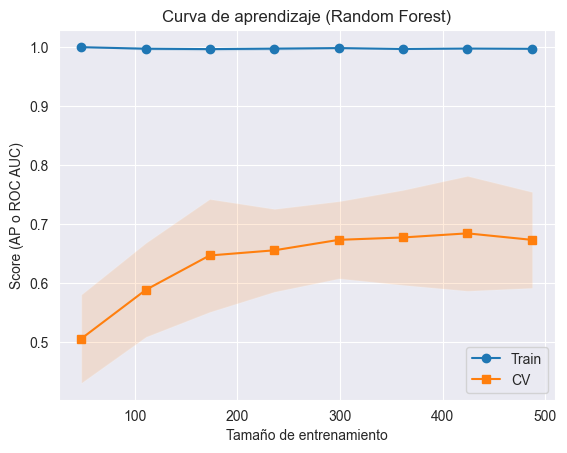

In [20]:

model = rf_pipe
X, y = X_train, y_train

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes = np.linspace(0.1, 1.0, 8)
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model,
    X=X, y=y,
    train_sizes=train_sizes,
    cv=cv,
    scoring="average_precision",   # o "roc_auc"
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean,   val_std   = val_scores.mean(axis=1),   val_scores.std(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker="o", label="Train")
plt.plot(train_sizes, val_mean,   marker="s", label="CV")
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15)
plt.fill_between(train_sizes, val_mean-val_std,     val_mean+val_std,     alpha=0.15)
plt.xlabel("Tamaño de entrenamiento")
plt.ylabel("Score (AP o ROC AUC)")
plt.title("Curva de aprendizaje (Random Forest)")
plt.legend(); plt.grid(True); plt.show()

In [23]:
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42,
    bootstrap=True
)

param_grid = {
    "clf__max_depth": [8, 10, 12],
    "clf__min_samples_leaf": [3, 5, 8],
    "clf__min_samples_split": [8, 12, 16],
    "clf__max_features": ["sqrt", 0.3, 0.5],
    "clf__max_samples": [0.7, 0.8, 0.9]  # si está disponible en tu versión
}

rf_pipe = Pipeline([("prep", preprocessor), ("clf", rf)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(rf_pipe, param_grid, scoring="average_precision",
                    cv=cv, n_jobs=-1, refit=True, verbose=0)
grid.fit(X_train, y_train)

print("Mejores params:", grid.best_params_)
rf_best = grid.best_estimator_

Mejores params: {'clf__max_depth': 8, 'clf__max_features': 0.3, 'clf__max_samples': 0.7, 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 16}


In [25]:
# Probabilidades y predicciones (umbral 0.5)
proba  = rf_best.predict_proba(X_test)[:, 1]   # si tu modelo se llama distinto, cámbialo
pred05 = (proba >= 0.5).astype(int)

# Métricas
roc  = roc_auc_score(y_test, proba)
ap   = average_precision_score(y_test, proba)
print(f"ROC AUC : {roc:.3f}")
print(f"PR-AUC  : {ap:.3f}")

print("\n== Classification report (thr=0.5) ==")
print(classification_report(y_test, pred05, digits=3,
                            target_names=["No deserta (0)", "Deserta (1)"]))

ROC AUC : 0.935
PR-AUC  : 0.729

== Classification report (thr=0.5) ==
                precision    recall  f1-score   support

No deserta (0)      0.947     0.947     0.947       133
   Deserta (1)      0.650     0.650     0.650        20

      accuracy                          0.908       153
     macro avg      0.799     0.799     0.799       153
  weighted avg      0.908     0.908     0.908       153



In [26]:
# Matriz de confusión (conteos y %)
cm = confusion_matrix(y_test, pred05, labels=[0,1])
cm_df = pd.DataFrame(cm, index=["Real 0","Real 1"], columns=["Pred 0","Pred 1"])
print("\nMatriz de confusión (conteos):"); display(cm_df)

cm_pct = (cm/cm.sum())*100
cm_pct_df = pd.DataFrame(np.round(cm_pct,2), index=["Real 0","Real 1"], columns=["Pred 0","Pred 1"])
print("Matriz de confusión (% del total):"); display(cm_pct_df)


Matriz de confusión (conteos):


,Pred 0,Pred 1
Real 0,126,7
Real 1,7,13


Matriz de confusión (% del total):


,Pred 0,Pred 1
Real 0,82.35,4.58
Real 1,4.58,8.50


In [27]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, proba)
thr = np.r_[0.0, thr]
f1 = 2*prec*rec / np.where(prec+rec==0, np.inf, prec+rec)
i = np.nanargmax(f1); thr_f1 = float(thr[i])

pred_f1 = (proba >= thr_f1).astype(int)
print(f"\nUmbral F1* = {thr_f1:.3f} | precision={prec[i]:.3f} recall={rec[i]:.3f} f1={f1[i]:.3f}")
print(classification_report(y_test, pred_f1, digits=3,
                            target_names=["No deserta (0)", "Deserta (1)"]))
cm = confusion_matrix(y_test, pred_f1, labels=[0,1])
display(pd.DataFrame(cm, index=["Real 0","Real 1"], columns=["Pred 0","Pred 1"]))



Umbral F1* = 0.453 | precision=0.652 recall=0.750 f1=0.698
                precision    recall  f1-score   support

No deserta (0)      0.961     0.932     0.947       133
   Deserta (1)      0.625     0.750     0.682        20

      accuracy                          0.908       153
     macro avg      0.793     0.841     0.814       153
  weighted avg      0.917     0.908     0.912       153



,Pred 0,Pred 1
Real 0,124,9
Real 1,5,15


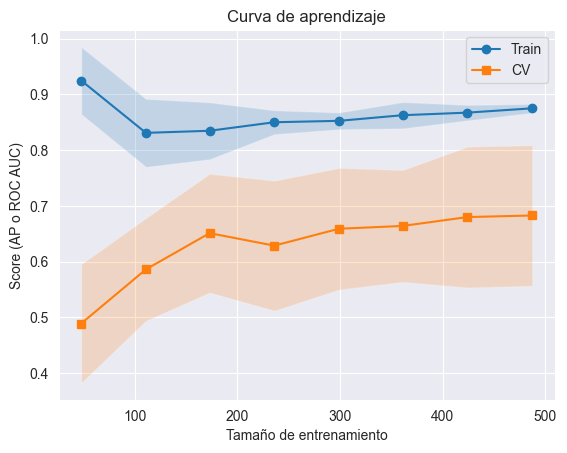

In [29]:
model = rf_best

# === 2) Usa tu conjunto de entrenamiento ya cargado ===
X, y = X_train, y_train

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 8)

sizes, tr, va = learning_curve(
    estimator=model,
    X=X, y=y,
    train_sizes=train_sizes,
    cv=cv,
    scoring="average_precision",   # o "roc_auc"
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

tr_m, tr_s = tr.mean(axis=1), tr.std(axis=1)
va_m, va_s = va.mean(axis=1), va.std(axis=1)

plt.figure()
plt.plot(sizes, tr_m, marker="o", label="Train")
plt.plot(sizes, va_m, marker="s", label="CV")
plt.fill_between(sizes, tr_m-tr_s, tr_m+tr_s, alpha=0.2)
plt.fill_between(sizes, va_m-va_s, va_m+va_s, alpha=0.2)
plt.xlabel("Tamaño de entrenamiento")
plt.ylabel("Score (AP o ROC AUC)")
plt.title("Curva de aprendizaje")
plt.legend(); plt.grid(True); plt.show()